Saving bank.csv to bank (1).csv
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'
unzip:  cannot find or open bank-marketing-dataset.zip, bank-marketing-dataset.zip.zip or bank-marketing-dataset.zip.ZIP.
Da

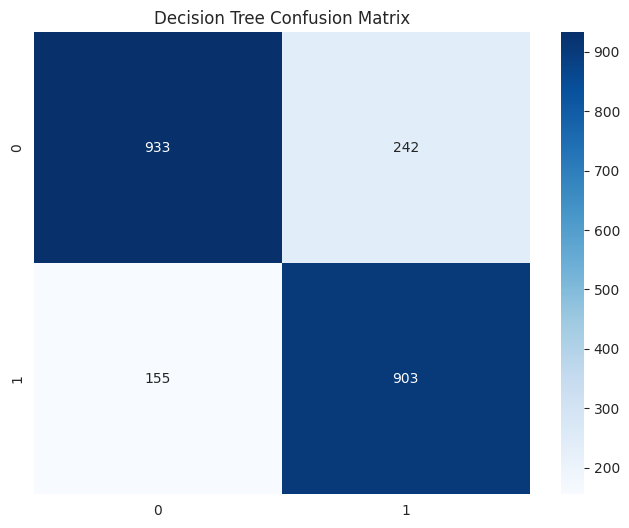

In [ ]:
# ==========================================================
# DECISION TREE & RANDOM FOREST CLASSIFICATION
# Bank Marketing Dataset
# ==========================================================

# -------------------------------
# STEP 1: Install & Setup Kaggle
# -------------------------------
!pip install -q kaggle

from google.colab import files
files.upload()  # Upload kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d janiobachmann/bank-marketing-dataset
!unzip bank-marketing-dataset.zip


# -------------------------------
# STEP 2: Import Libraries
# -------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8,6)


# -------------------------------
# STEP 3: Load Dataset
# -------------------------------
df = pd.read_csv("bank.csv")

print("Dataset Shape:", df.shape)
df.head()


# -------------------------------
# STEP 4: Data Preprocessing
# -------------------------------

# Convert target column (yes/no → 1/0)
df['deposit'] = df['deposit'].map({'yes':1, 'no':0})

# One-hot encoding categorical variables
df = pd.get_dummies(df, drop_first=True)

# Features & Target
X = df.drop("deposit", axis=1)
y = df["deposit"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# ==========================================================
# 1️⃣ DECISION TREE CLASSIFIER
# ==========================================================

dt = DecisionTreeClassifier(random_state=42)

# Hyperparameter tuning
param_grid_dt = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(dt, param_grid_dt, cv=5)
grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_

y_pred_dt = best_dt.predict(X_test)

print("\nDECISION TREE RESULTS")
print("Best Parameters:", grid_dt.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))


# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree Confusion Matrix")
plt.show()


# ==========================================================
# 2️⃣ RANDOM FOREST CLASSIFIER
# ==========================================================

rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(rf, param_grid_rf, cv=5)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)

print("\nRANDOM FOREST RESULTS")
print("Best Parameters:", grid_rf.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))


# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.show()


# ==========================================================
# 3️⃣ ROC CURVE COMPARISON
# ==========================================================

y_prob_dt = best_dt.predict_proba(X_test)[:,1]
y_prob_rf = best_rf.predict_proba(X_test)[:,1]

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

roc_auc_dt = auc(fpr_dt, tpr_dt)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.plot(fpr_dt, tpr_dt, label="Decision Tree AUC = %.2f" % roc_auc_dt)
plt.plot(fpr_rf, tpr_rf, label="Random Forest AUC = %.2f" % roc_auc_rf)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

print("Decision Tree AUC:", roc_auc_dt)
print("Random Forest AUC:", roc_auc_rf)